In [144]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,ConfusionMatrixDisplay
from sklearn.ensemble import AdaBoostClassifier
from catboost import CatBoostClassifier
import warnings

In [145]:
warnings.filterwarnings('ignore')

In [146]:
#read the dataset
df=pd.read_csv('Transformed_data/scaled_data.csv')

In [147]:
X=df.drop(columns="Loan_status",axis=1)
Y=df['Loan_status']

selecting the best model for prediction...

In [148]:
models = {
    "Random Forest": RandomForestClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "Logistic Regression": LogisticRegression(),
     "K-Neighbors Classifier": KNeighborsClassifier(),
    "XGBClassifier": XGBClassifier(), 
     "CatBoosting Classifier": CatBoostClassifier(verbose=False),
    "AdaBoost Classifier": AdaBoostClassifier()
}

In [149]:
#write a function to generate the report...
def evaluate_model(x,y,models):
    #train test split
    X_train,X_test,Y_train,Y_test=train_test_split(x,y,random_state=42,test_size=0.2)

    models_list = []
    scores = []
    
    for i in range(len(list(models))):
        model = list(models.values())[i]
        model.fit(X_train, Y_train) # Train model

        # Make predictions
        y_pred = model.predict(X_test)

        score = accuracy_score(Y_test,y_pred)
        
        model_name = list(models.keys())[i]
        print(f'---- score for --- {model_name} ----')
        print(f"{score}")
        models_list.append(model_name)
        scores.append(score)
    
    report = pd.DataFrame()
    report['Model_name'] = models_list
    report['Score'] = scores        
    return report


In [150]:
evaluate_model(X,Y,models)

---- score for --- Random Forest ----
0.7479674796747967
---- score for --- Decision Tree ----
0.6585365853658537
---- score for --- Logistic Regression ----
0.7886178861788617
---- score for --- K-Neighbors Classifier ----
0.7317073170731707
---- score for --- XGBClassifier ----
0.7479674796747967
---- score for --- CatBoosting Classifier ----
0.7804878048780488
---- score for --- AdaBoost Classifier ----
0.7642276422764228


,Model_name,Score
0,Random Forest,0.747967
1,Decision Tree,0.658537
2,Logistic Regression,0.788618
3,K-Neighbors Classifier,0.731707
4,XGBClassifier,0.747967
5,CatBoosting Classifier,0.780488
6,AdaBoost Classifier,0.764228


Heree the best model is Logistic Regression ,Achieve 78% accuracy

Now,Tune the model for more better prediction

In [151]:
from sklearn.model_selection import GridSearchCV

In [152]:
paramgrid={
    "penalty":['l1','l2','elasticnet'],
    "C":[0.1,0.2,0.4,0.3,0.8,0.7],
    "solver":['lbfgs','liblinear','newton-cg','newton-cholesky','‘newton-cholesky','saga']
}

In [153]:
gridsearchcv=GridSearchCV(estimator=LogisticRegression(),cv=3,param_grid=paramgrid)

In [154]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,random_state=42,test_size=0.2)

In [155]:
gridsearchcv.fit(X_train,Y_train)

GridSearchCV(cv=3, estimator=LogisticRegression(),
             param_grid={'C': [0.1, 0.2, 0.4, 0.3, 0.8, 0.7],
                         'penalty': ['l1', 'l2', 'elasticnet'],
                         'solver': ['lbfgs', 'liblinear', 'newton-cg',
                                    'newton-cholesky', '‘newton-cholesky',
                                    'saga']})

In [156]:
gridsearchcv.best_estimator_

LogisticRegression(C=0.4)

In [157]:
gridsearchcv.best_score_#here aheice nearly 82% accuracy

0.8166741483365754

In [158]:
gridsearchcv.best_params_

{'C': 0.4, 'penalty': 'l2', 'solver': 'lbfgs'}

In [159]:
Y_pred_train=gridsearchcv.best_estimator_.predict(X_train)
Y_pred_test=gridsearchcv.best_estimator_.predict(X_test)

In [160]:
accuracy_score(Y_pred_test,Y_test)#test accurcy,model generlaizing well here

0.7886178861788617

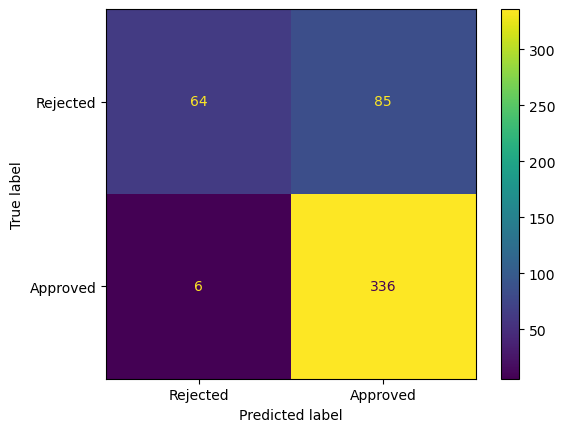

In [161]:
ConfusionMatrixDisplay.from_predictions(Y_train,Y_pred_train,display_labels=["Rejected","Approved"])

#by this conclusion we have to reject the loan approval bt our model has approve it ,so we want here better decision
#in this terms


In this we want higher Precision model

In [162]:
from sklearn.metrics import auc,roc_curve,recall_score,precision_score

In [163]:
precision_score(Y_test,Y_pred_test)#heere we want higher precision model

0.7596153846153846

In [164]:
recall_score(Y_test,Y_pred_test)

0.9875

In [165]:
LSG=LogisticRegression(C=0.4,penalty="l2",solver="lbfgs")#train the model with optimal paramter we get from gridsearch cv

In [166]:
LSG.fit(X_train,Y_train)

LogisticRegression(C=0.4)

In [167]:
y_pred=LSG.predict(X_train)

In [168]:
#calcualte auc curve for judging better model perfomance
prob_y_pred=LSG.predict_proba(X_test)[:,1]

In [169]:
prob_y_pred#probability of 1 class of loan approval

array([0.7520947 , 0.75882051, 0.80923925, 0.78332642, 0.78046591,
       0.79480754, 0.81477816, 0.80873485, 0.74515384, 0.81528057,
       0.18033749, 0.74042235, 0.81656676, 0.78619424, 0.90066145,
       0.84030168, 0.80066531, 0.81644029, 0.79644999, 0.81063308,
       0.74322425, 0.80440127, 0.76011959, 0.77745978, 0.95128308,
       0.80532563, 0.72684083, 0.73108337, 0.75724755, 0.89895804,
       0.87981611, 0.85043296, 0.74897425, 0.83145924, 0.78014451,
       0.04533201, 0.77458662, 0.88104321, 0.84244661, 0.77641532,
       0.79265221, 0.77344092, 0.83791357, 0.78111227, 0.83047563,
       0.77146241, 0.8012454 , 0.11631748, 0.07997844, 0.11168535,
       0.66436661, 0.78701287, 0.09199307, 0.71643379, 0.77551141,
       0.69216715, 0.80570377, 0.76866214, 0.08558583, 0.79866919,
       0.11737908, 0.81782126, 0.13565845, 0.75492577, 0.85221817,
       0.79675578, 0.86560263, 0.91304083, 0.89907478, 0.73234321,
       0.07457215, 0.83420958, 0.78154707, 0.81083785, 0.13339

In [170]:
fpr,tpr,threshold=roc_curve(Y_test,prob_y_pred)

In [171]:
#auc
auc(fpr,tpr)#close to 70% our model generalize better 

0.6959302325581396

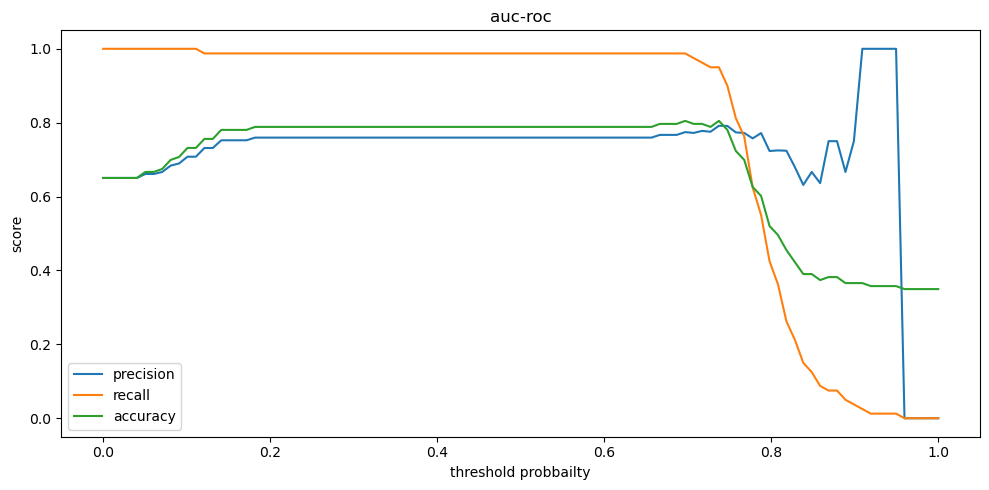

In [172]:
#Tune the Threshold for better precision
import matplotlib.pyplot as plt
thresholds=np.linspace(0,1,100)
precision=[]
recall=[]
accuracy=[]
for threshold in thresholds:
    y_pred_proba=(prob_y_pred>=threshold).astype(int)
    accuracy_=accuracy_score(Y_test,y_pred_proba)
    precision_=precision_score(Y_test,y_pred_proba)
    recall_=recall_score(Y_test,y_pred_proba)
    precision.append(precision_)
    recall.append(recall_)
    accuracy.append(accuracy_)
#now plot
plt.figure(figsize=(10,5))
plt.plot(thresholds,precision,label='precision')
plt.plot(thresholds,recall,label='recall')
plt.plot(thresholds,accuracy,label='accuracy')
plt.xlabel('threshold probbailty')
plt.ylabel('score')
plt.title('auc-roc')
plt.legend()
plt.tight_layout()
plt.show()

In [173]:
new_prob_pred=np.where(prob_y_pred>0.75,1,0)

In [174]:
precision_score(Y_test,new_prob_pred)# precision also increased...

0.7865168539325843

In [175]:
fpr,tpr,threshold=roc_curve(Y_test,new_prob_pred)

In [180]:
y_pred_test=LSG.predict(X_test)

In [181]:
accuracy_score(Y_test,y_pred_test)

0.7886178861788617

In [182]:
auc(fpr,tpr)#here improve of auc curve

0.7165697674418605

In [188]:
#Now save the model
import pickle
import os
os.makedirs("model",exist_ok=True)
with open("model/model.pkl","wb")as file:
    pickle.dump(LSG,file)

In [190]:
threshold=0.75
with open("Threshold/threshold.pkl","wb") as file:
    pickle.dump(threshold,file)